# Analyzing Crop Production Across India

##### India, an agrarian economy, has witnessed significant transformations in its agricultural patterns due to factors such as urbanization, climate change, and technological advances. Analyzing these shifts at the district level provides insights into food security, resource allocation, and sustainable farming practices. 

##### However, while existing studies extensively explore macro-level trends (state or national scale), granular district-level insights over extended timeframes (1997–2023) remain underexplored. This project aims at trying to explore this segment in Indian crop production

##### For context Warangal is the city I spent most of my first 12 years in. Its the city where most of my relatives live in. Since its very close to my heart thats the city I'm going to be using in all of the examples 

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
import scipy.stats as stats
import seaborn as sns 
import geopandas as gpd

import folium
from folium import plugins
import branca.colormap as cm

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.tree import plot_tree
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

from sklearn.decomposition import PCA

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [2]:
APY = pd.read_csv("APY.csv")
rainfall = pd.read_csv("rainfall.csv")
temp = pd.read_csv("temperature.csv")
agri_pricing = pd.read_csv("agr_csv2.csv")
india_map = gpd.read_file('States/India_State_Boundary.shp')
india_dt = gpd.read_file('India Shape/india_ds.shp')

APY_dict = {
    'APY': APY,
    'rainfall': rainfall, 
    'temp': temp,
    'agri_pricing': agri_pricing
}

for i, j in APY_dict.items(): 
    j.dropna(axis=0)
    print(f"{i}'s shape is {j.shape}")

india_dt.columns.tolist()

APY's shape is (345336, 8)
rainfall's shape is (58, 18)
temp's shape is (58, 6)
agri_pricing's shape is (2238, 9)


['DST_ID', 'DISTRICT', 'STATE', 'geometry']

### Start off with creating chloropleth maps of production of crops per state

In [3]:
# mapping the statenames in APY to shapefile so that there's consistency
STATE_NAME_MAPPING = {
    'Andaman and Nicobar Island': 'Andaman & Nicobar',
    'Chhattisgarh': 'Chhattishgarh',
    'Dadra and Nagar Haveli': 'Daman and Diu and Dadra and Nagar Haveli',
    'THE DADRA AND NAGAR HAVELI': 'Daman and Diu and Dadra and Nagar Haveli',
    'Daman and Diu': 'Daman and Diu and Dadra and Nagar Haveli',
    'Tamil Nadu': 'Tamilnadu',
    'Telangana': 'Telengana',
    'Laddak': 'Ladakh',
    'CHANDIGARH': 'Chandigarh'
}

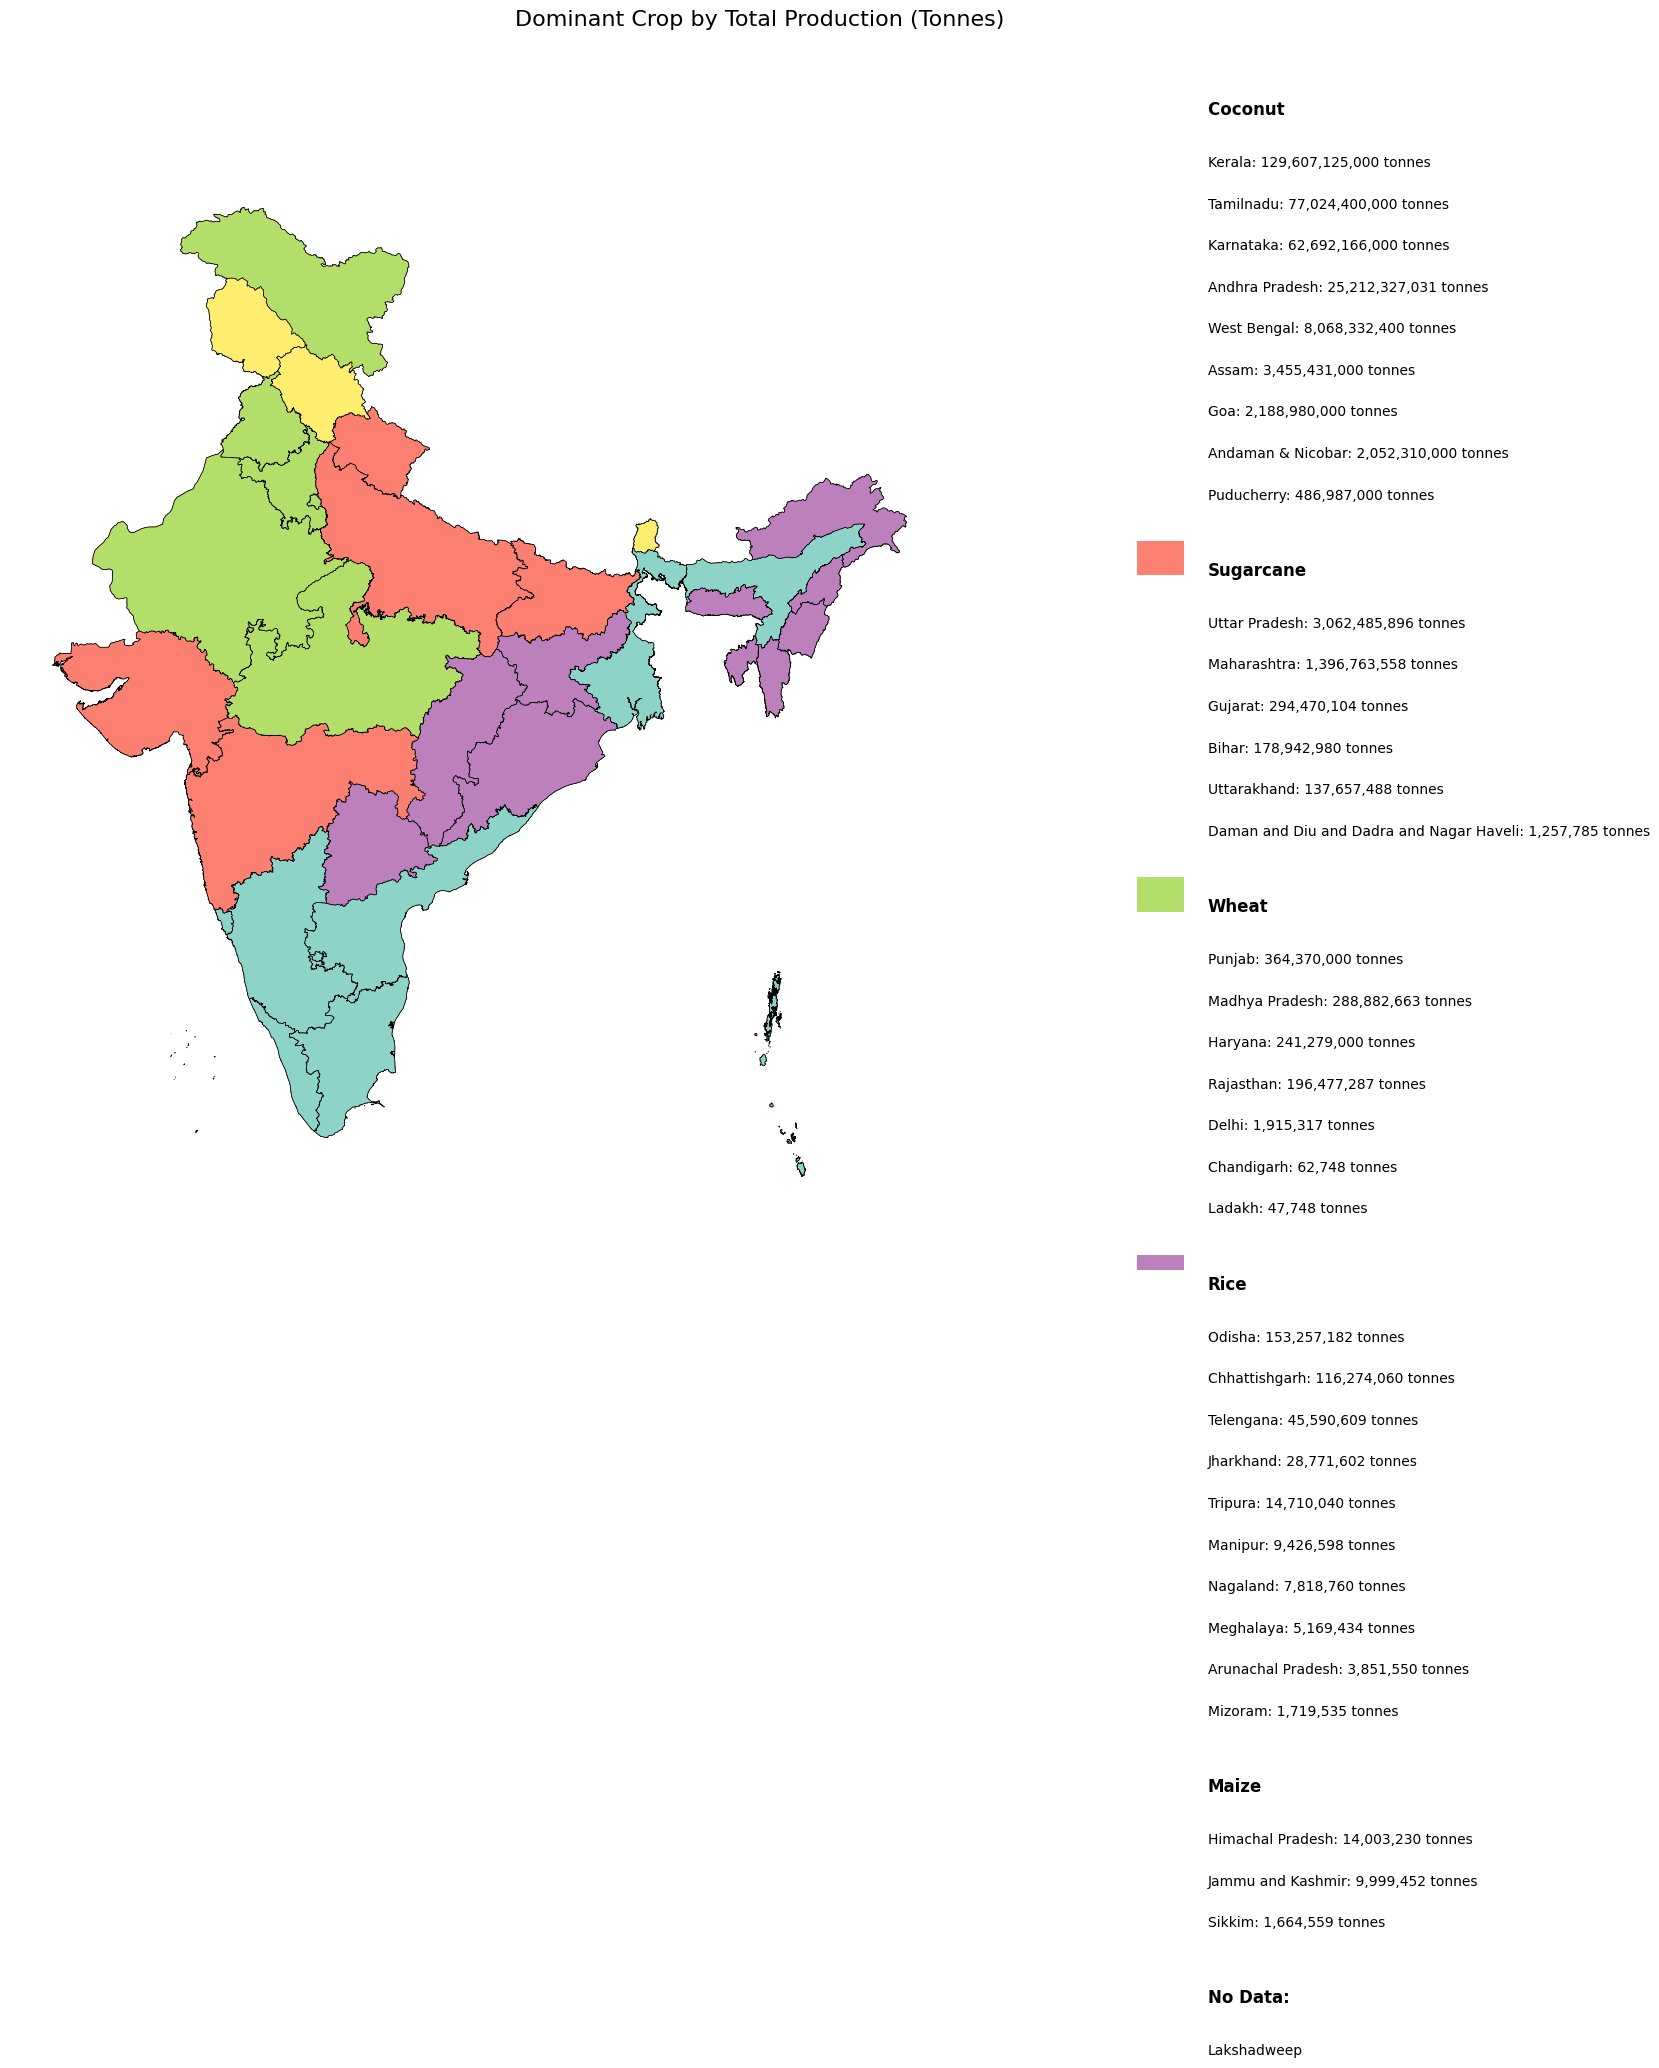

In [4]:
# Calculate the Total Production of each state and plot it

APY_standardized = APY.copy()
APY_standardized['State'] = APY_standardized['State'].replace(STATE_NAME_MAPPING)

total_production = APY_standardized.groupby(['State', 'Crop'])['Production'].sum().reset_index()

dominant_crops = total_production.loc[
    total_production.groupby('State')['Production'].idxmax()
]

dominant_crops = dominant_crops.sort_values('Production', ascending=False)

fig = plt.figure(figsize=(20, 15))
gs = plt.GridSpec(1, 2, width_ratios=[2, 1])  # Adjust ratio for map and legend
ax_map = fig.add_subplot(gs[0])
ax_legend = fig.add_subplot(gs[1])

# Create color mapping
unique_crops = dominant_crops['Crop'].unique()
colors = plt.cm.Set3(np.linspace(0, 1, len(unique_crops)))
crop_colors = dict(zip(unique_crops, colors))

# Merge with geographic data
merged_data = india_map.merge(
    dominant_crops,
    how='left',
    left_on='State_Name',
    right_on='State'
)

# Plot base map
merged_data.plot(
    ax=ax_map,
    color='lightgray',
    edgecolor='black',
    linewidth=0.5
)

# Plot states with data
for crop in unique_crops:
    crop_states = merged_data[merged_data['Crop'] == crop]
    if not crop_states.empty:
        crop_states.plot(
            ax=ax_map,
            color=crop_colors[crop],
            edgecolor='black',
            linewidth=0.5
        )

# Create detailed legend
ax_legend.axis('off')
y_position = 1
line_height = 0.03

# Group states by crop
for crop in unique_crops:
    crop_data = dominant_crops[dominant_crops['Crop'] == crop]
    
    # Add crop header
    ax_legend.add_patch(mpatches.Rectangle((0.1, y_position), 0.1, line_height,
                                         facecolor=crop_colors[crop]))
    ax_legend.text(0.25, y_position, f'{crop}', fontsize=12, fontweight='bold')
    y_position -= line_height * 1.5
    
    # Add states for this crop
    for _, row in crop_data.iterrows():
        text = f"{row['State']}: {row['Production']:,.0f} tonnes"
        ax_legend.text(0.25, y_position, text, fontsize=10)
        y_position -= line_height * 1.2
    
    y_position -= line_height  # Extra space between crops

# Add "No Data" entry
if len(merged_data[merged_data['Crop'].isna()]) > 0:
    ax_legend.add_patch(mpatches.Rectangle((0.1, y_position), 0.1, line_height,
                                         facecolor='lightgray'))
    ax_legend.text(0.25, y_position, 'No Data:', fontsize=12, fontweight='bold')
    y_position -= line_height * 1.5
    
    no_data_states = merged_data[merged_data['Crop'].isna()]['State_Name'].unique()
    for state in sorted(no_data_states):
        ax_legend.text(0.25, y_position, state, fontsize=10)
        y_position -= line_height * 1.2

plt.suptitle('Dominant Crop by Total Production (Tonnes)', y=0.95, fontsize=16)
ax_map.axis('off')
plt.show()

### Now implement the production per hectare

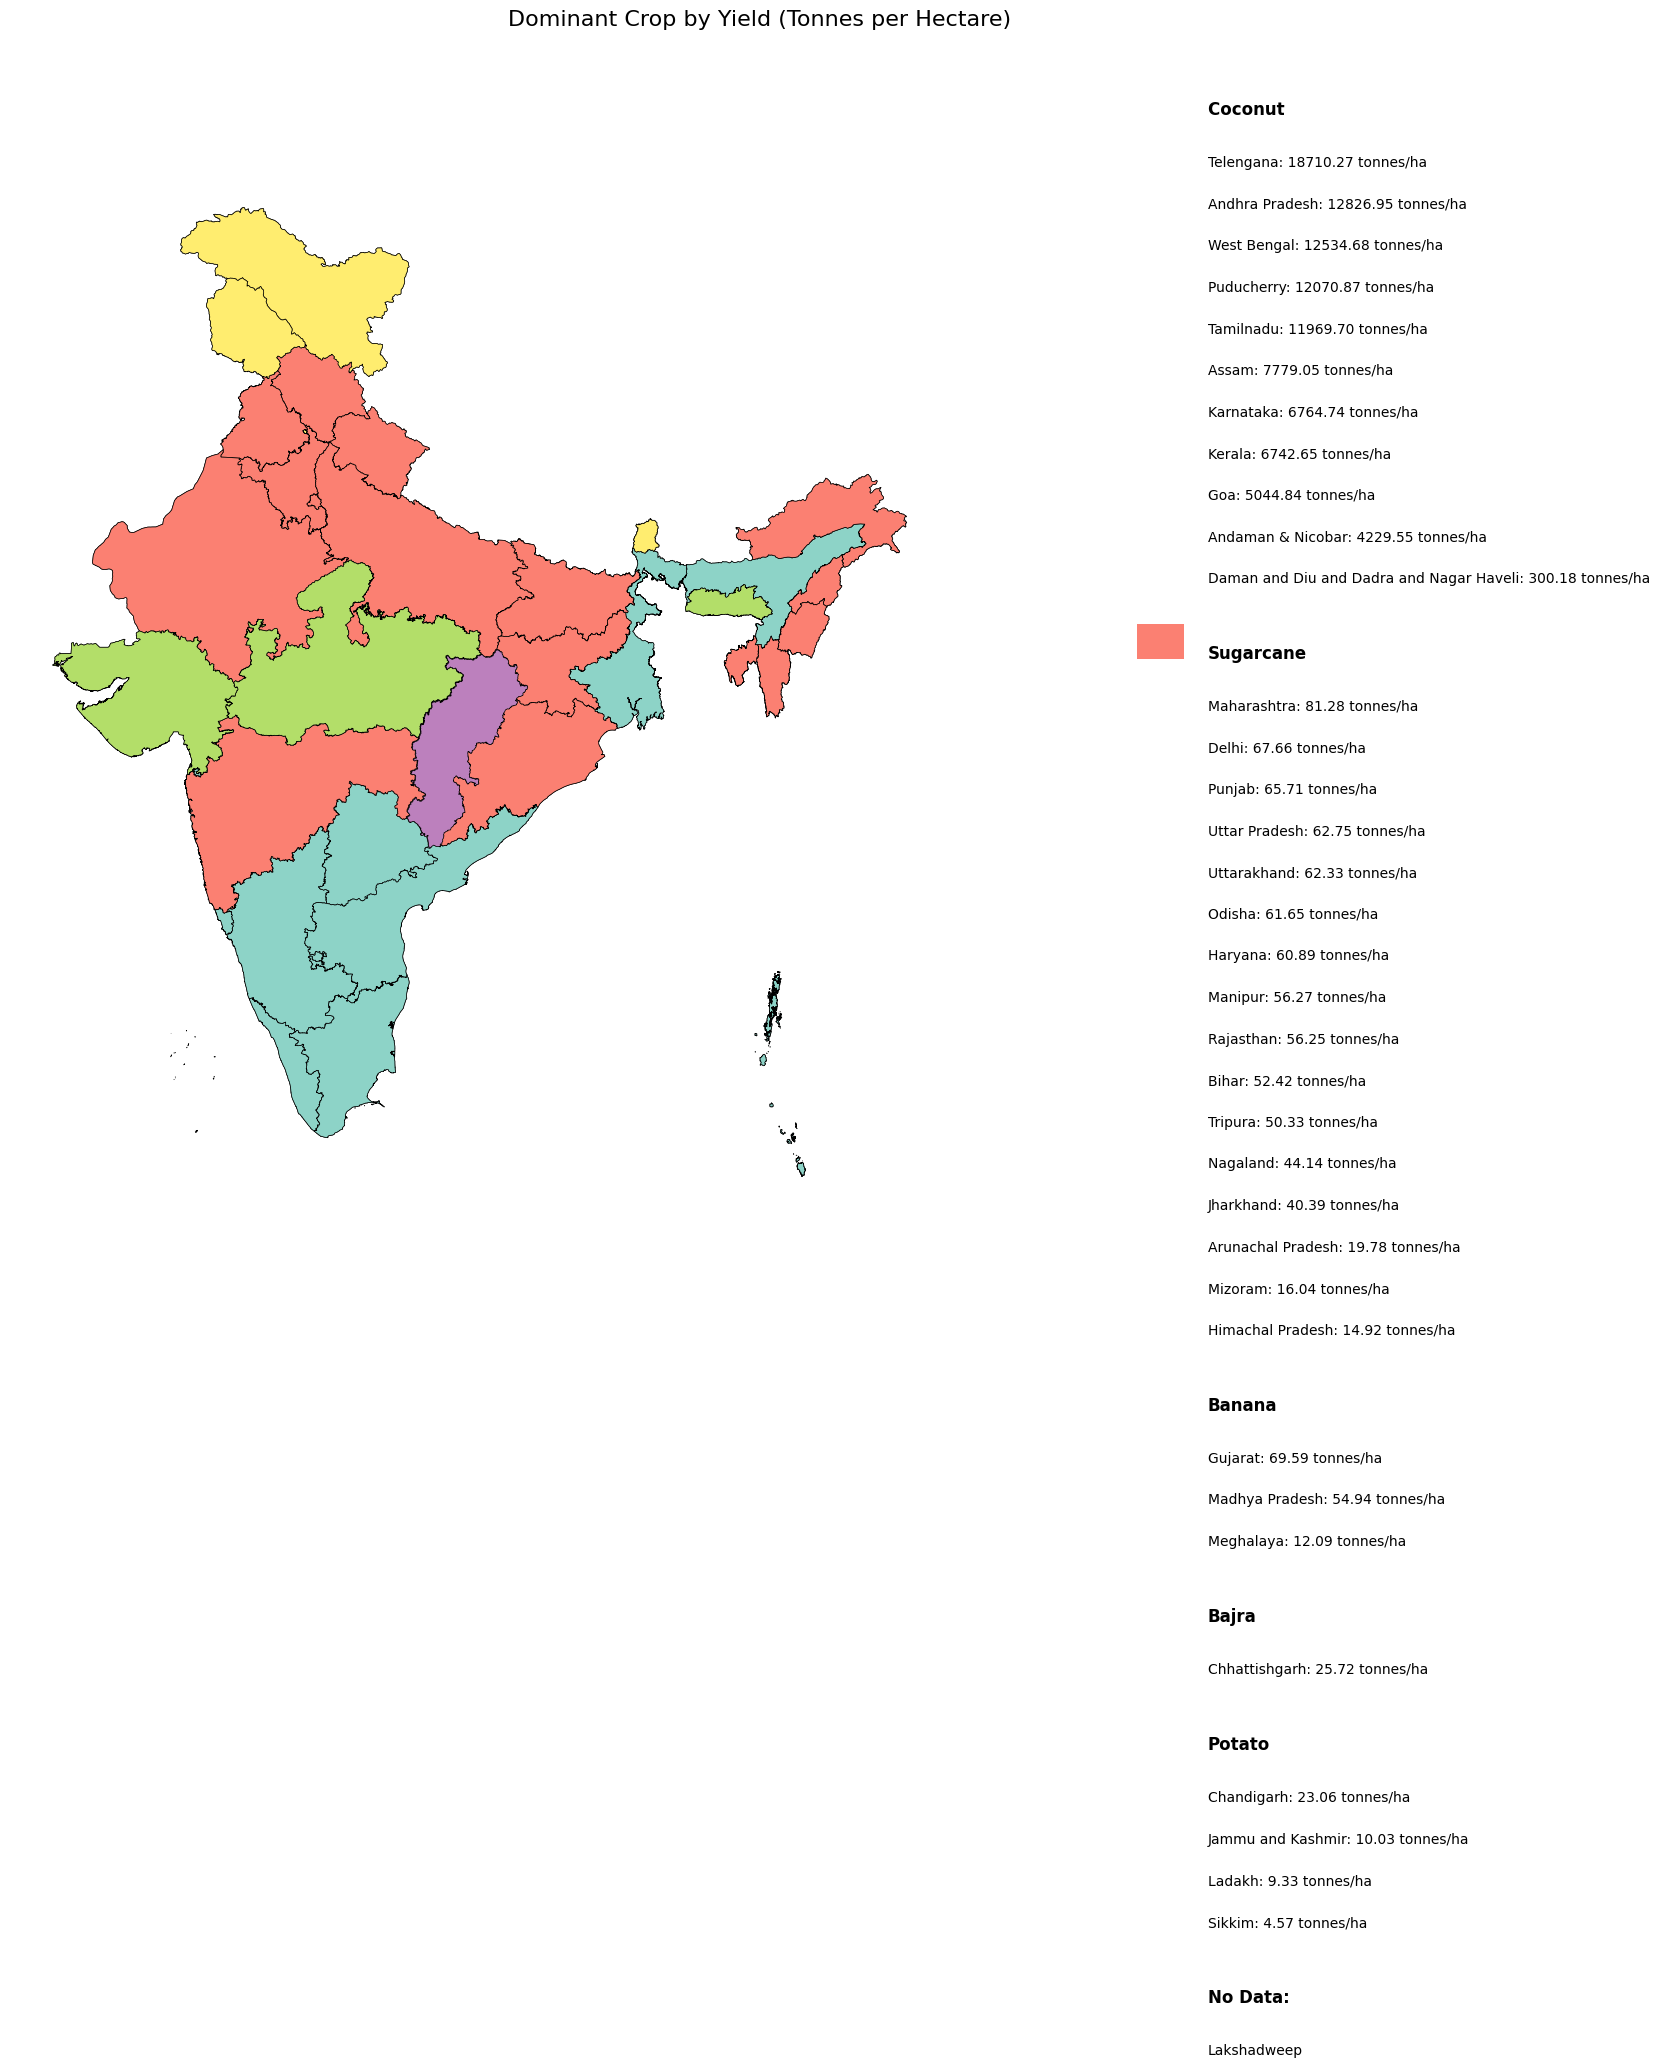

In [5]:
# Calculate the Total Production/Hectare of each state and plot it

APY_standardized = APY.copy()
APY_standardized['State'] = APY_standardized['State'].replace(STATE_NAME_MAPPING)

# Calculate yield for each state-crop
state_yields = APY_standardized.groupby(['State', 'Crop']).agg({
    'Production': 'sum',
    'Area ': 'sum'
}).reset_index()
state_yields['Yield'] = state_yields['Production'] / state_yields['Area ']

# Find crop with maximum yield for each state
dominant_yields = state_yields.loc[
    state_yields.groupby('State')['Yield'].idxmax()
]

# Sort states by yield for legend
dominant_yields = dominant_yields.sort_values('Yield', ascending=False)

# Create visualization
fig = plt.figure(figsize=(20, 15))
gs = plt.GridSpec(1, 2, width_ratios=[2, 1])  # Adjust ratio for map and legend
ax_map = fig.add_subplot(gs[0])
ax_legend = fig.add_subplot(gs[1])

# Create color mapping
unique_crops = dominant_yields['Crop'].unique()
colors = plt.cm.Set3(np.linspace(0, 1, len(unique_crops)))
crop_colors = dict(zip(unique_crops, colors))

# Merge with geographic data
merged_data = india_map.merge(
    dominant_yields,
    how='left',
    left_on='State_Name',
    right_on='State'
)

# Plot base map
merged_data.plot(
    ax=ax_map,
    color='lightgray',
    edgecolor='black',
    linewidth=0.5
)

# Plot states with data
for crop in unique_crops:
    crop_states = merged_data[merged_data['Crop'] == crop]
    if not crop_states.empty:
        crop_states.plot(
            ax=ax_map,
            color=crop_colors[crop],
            edgecolor='black',
            linewidth=0.5
        )

# Create detailed legend
ax_legend.axis('off')
y_position = 1
line_height = 0.03

# Group states by crop
for crop in unique_crops:
    crop_data = dominant_yields[dominant_yields['Crop'] == crop]
    
    # Add crop header
    ax_legend.add_patch(mpatches.Rectangle((0.1, y_position), 0.1, line_height,
                                         facecolor=crop_colors[crop]))
    ax_legend.text(0.25, y_position, f'{crop}', fontsize=12, fontweight='bold')
    y_position -= line_height * 1.5
    
    # Add states for this crop
    for _, row in crop_data.iterrows():
        text = f"{row['State']}: {row['Yield']:.2f} tonnes/ha"
        ax_legend.text(0.25, y_position, text, fontsize=10)
        y_position -= line_height * 1.2
    
    y_position -= line_height  # Extra space between crops

# Add "No Data" entry
if len(merged_data[merged_data['Crop'].isna()]) > 0:
    ax_legend.add_patch(mpatches.Rectangle((0.1, y_position), 0.1, line_height,
                                         facecolor='lightgray'))
    ax_legend.text(0.25, y_position, 'No Data:', fontsize=12, fontweight='bold')
    y_position -= line_height * 1.5
    
    no_data_states = merged_data[merged_data['Crop'].isna()]['State_Name'].unique()
    for state in sorted(no_data_states):
        ax_legend.text(0.25, y_position, state, fontsize=10)
        y_position -= line_height * 1.2

plt.suptitle('Dominant Crop by Yield (Tonnes per Hectare)', y=0.95, fontsize=16)
ax_map.axis('off')
plt.show()

### Implementing K-NN to figure out what parts of India grow what major crop

#### First lets group the data by district and crop so that each row is a district and each column is a crop and the entries are production amounts
#### And then scales the data to create target variable (y) with the dominant crop for each district

In [6]:
# Create feature matrix
# First summarize production by district and crop
APY_knn = APY.copy()
district_crop_pivot = APY_knn.pivot_table(
    index='District',
    columns='Crop',
    values='Production',
    aggfunc='sum',
    fill_value=0
)

# Create target variable (dominant crop for each district)
district_crop_summary = APY_knn.groupby(['District', 'Crop'])['Production'].sum().reset_index()
dominant_crops = district_crop_summary.loc[
    district_crop_summary.groupby('District')['Production'].idxmax()
]

scaler = StandardScaler()
X = scaler.fit_transform(district_crop_pivot)
y = dominant_crops['Crop']

# Print summary statistics
print("\n=== Dataset Summary ===")
print(f"Number of districts: {len(district_crop_pivot)}")
print(f"Number of crops (features): {len(district_crop_pivot.columns)}")
print(f"Number of unique target crops: {len(y.unique())}")


=== Dataset Summary ===
Number of districts: 707
Number of crops (features): 55
Number of unique target crops: 21


In [7]:
# Get prepared data using prepare_for_knn
district_names = district_crop_pivot.index

# Apply K-means clustering
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(X)

# Apply PCA for visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


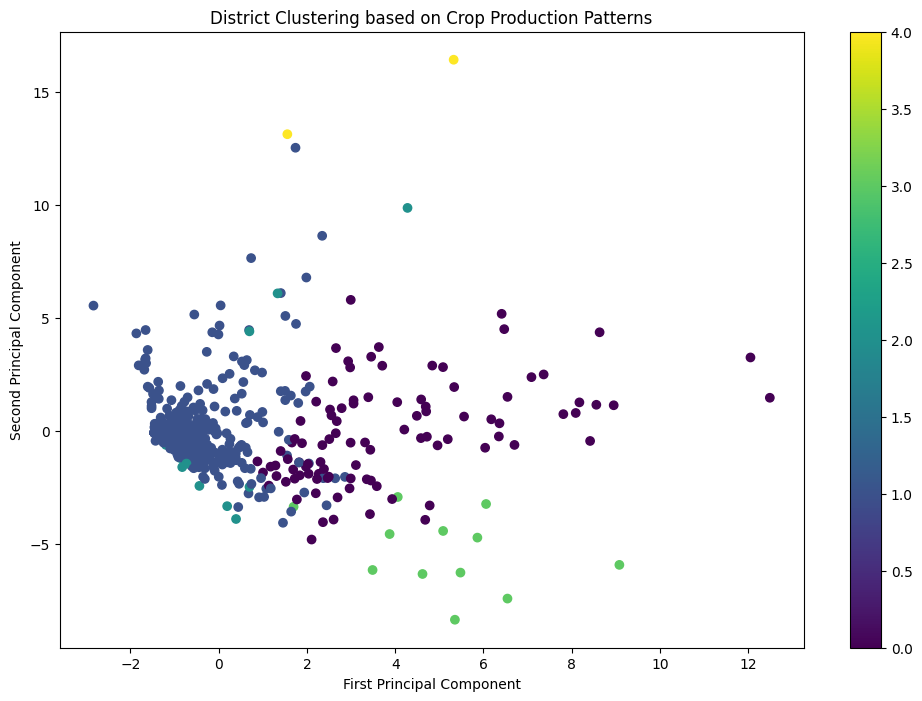

In [8]:
# Create visualization
plt.figure(figsize=(12, 8))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=labels, cmap='viridis')
plt.title('District Clustering based on Crop Production Patterns')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.colorbar(scatter)
plt.show()

# Create cluster DataFrame
cluster_APY = pd.DataFrame({
    'District': district_names,
    'Cluster': labels,
    'Dominant_Crop': y
})

# Create district crop summary for analysis
district_crop_summary = APY.groupby(['District', 'Crop'])['Production'].sum().reset_index()

In [9]:
# Analyze clusters
print("\n=== Cluster Analysis ===")
for cluster in range(n_clusters):
    cluster_districts = cluster_APY[cluster_APY['Cluster'] == cluster]['District']
    cluster_crops = district_crop_summary[
        district_crop_summary['District'].isin(cluster_districts)
    ]
    
    print(f"\nCluster {cluster} characteristics:")
    print("Number of districts:", len(cluster_districts))
    print("Top 5 crops by production:")
    print(cluster_crops.groupby('Crop')['Production']
            .sum()
            .sort_values(ascending=False)
            .head()
    )
    print("\nDistricts in this cluster:")
    print(cluster_districts.tolist())

# Print cluster summary
print("\n=== Cluster Summary ===")
print("\nNumber of districts in each cluster:")
print(cluster_APY['Cluster'].value_counts())

print("\nDominant crops by cluster:")
print(cluster_APY.groupby('Cluster')['Dominant_Crop'].value_counts())


=== Cluster Analysis ===

Cluster 0 characteristics:
Number of districts: 98
Top 5 crops by production:
Crop
Coconut         8.404252e+09
Sugarcane       2.119517e+09
Wheat           3.533353e+08
Cotton(lint)    2.926095e+08
Rice            2.285058e+08
Name: Production, dtype: float64

Districts in this cluster:
['ADILABAD', 'AHMEDNAGAR', 'AKOLA', 'AMRAVATI', 'AMRELI', 'ANANTAPUR', 'ASHOKNAGAR', 'AURANGABAD', 'BAGALKOTE', 'BALAGHAT', 'BALLARI', 'BANDA', 'BARAN', 'BEED', 'BELAGAVI', 'BETUL', 'BHAVNAGAR', 'BIDAR', 'BULDHANA', 'CHANDRAPUR', 'CHHATARPUR', 'CHHINDWARA', 'CHITRADURGA', 'CHITTORGARH', 'DAMOH', 'DEWAS', 'DHAR', 'DHARWAD', 'DHULE', 'GADAG', 'GUNA', 'GUNTUR', 'HAMIRPUR', 'HAVERI', 'HINGOLI', 'HOSHANGABAD', 'INDORE', 'JABALPUR', 'JALAUN', 'JALGAON', 'JALNA', 'JAMNAGAR', 'JHALAWAR', 'JHANSI', 'JUNAGADH', 'KADAPA', 'KALABURAGI', 'KARIMNAGAR', 'KHARGONE', 'KOLHAPUR', 'KOPPAL', 'KOTA', 'KRISHNA', 'KURNOOL', 'LALITPUR', 'LATUR', 'MAHBUBNAGAR', 'MAHOBA', 'MANDSAUR', 'MEDAK', 'NAGPUR'

## What the Scatter Plot above means:

#### Clusters and Colors: 
* Each dot represents a district
* The colors represent different clusters (from dark purple to yellow)
* Districts with the same color have similar crop production patterns

#### Position Meaning:
* The x-axis (First Principal Component) and y-axis (Second Principal Component) represent combined patterns of crop production
* Districts that are close together on the plot have similar crop production patterns
* Districts that are far apart have very different patterns

#### Key Observations:
* There's a dense blue cluster on the left side (-2, 0), suggesting many districts share a common agricultural pattern
* A scattered purple cluster spreads across the right side, indicating districts with more unique patterns
* Some outlier districts appear at the top of the plot (around y=15), suggesting very distinctive production patterns
* The spread along both axes shows significant variation in how districts produce crops

#### Practical Interpretation:
* The large blue cluster likely represents districts with "typical" or common crop production patterns
* The scattered points on the right and top might be districts specializing in specific crops or having unique agricultural profiles
* The gradual transition between clusters suggests some districts have hybrid production patterns

### Now that we've covered what the scatter plot means, lets look at the geographical regions the clusters correspond to and majority of the crop

In [10]:
print("\nCluster assignments:")
print(cluster_APY.head(5))

print("\nDominant crops:")
print(dominant_crops.head(5))


Cluster assignments:
       District  Cluster Dominant_Crop
6      ADILABAD        0  Cotton(lint)
70   AGAR MALWA        1         Wheat
95         AGRA        1        Potato
111   AHMADABAD        1  Cotton(lint)
161  AHMEDNAGAR        0     Sugarcane

Dominant crops:
       District          Crop   Production
6      ADILABAD  Cotton(lint)    9684901.0
70   AGAR MALWA         Wheat    1474013.0
95         AGRA        Potato   27685472.0
111   AHMADABAD  Cotton(lint)    6020981.0
161  AHMEDNAGAR     Sugarcane  151667127.0


In [11]:
geo_data = india_dt.merge(
    cluster_APY,
    left_on='DISTRICT',
    right_on='District',
    how='left'
)

# Keep it as a GeoDataFrame
geo_data = gpd.GeoDataFrame(geo_data)

# Calculate centroids
geo_data['longitude'] = geo_data.geometry.centroid.x
geo_data['latitude'] = geo_data.geometry.centroid.y

In [12]:
# 1. Clean and prepare the data
geo_data['DISTRICT_CLEAN'] = geo_data['DISTRICT'].str.strip().str.upper()
cluster_APY_clean = cluster_APY.copy()
cluster_APY_clean['District'] = cluster_APY_clean['District'].str.strip().str.upper()

# 2. Perform merge with clean column names
geo_data_new = geo_data.merge(
    cluster_APY_clean,
    left_on='DISTRICT_CLEAN',
    right_on='District',
    how='left',
    suffixes=(None, '_y')  # This will prevent duplicate columns
).drop(columns=[col for col in geo_data.columns if col.endswith('_y')])

# 3. Convert back to GeoDataFrame
geo_data_new = gpd.GeoDataFrame(geo_data_new, geometry='geometry')


Original columns in geo_data:
['DST_ID', 'DISTRICT', 'STATE', 'geometry']

Original columns in cluster_data:
['District', 'Cluster', 'Dominant_Crop']

Columns after merge:
['DST_ID', 'DISTRICT', 'STATE', 'geometry', 'DISTRICT_CLEAN', 'District', 'Cluster', 'Dominant_Crop']

Data Summary:
Total districts: 482
Districts with cluster assignments: 401

Cluster distribution:
1.0    306
NaN     81
0.0     77
3.0     10
2.0      7
4.0      1
Name: Cluster, dtype: int64


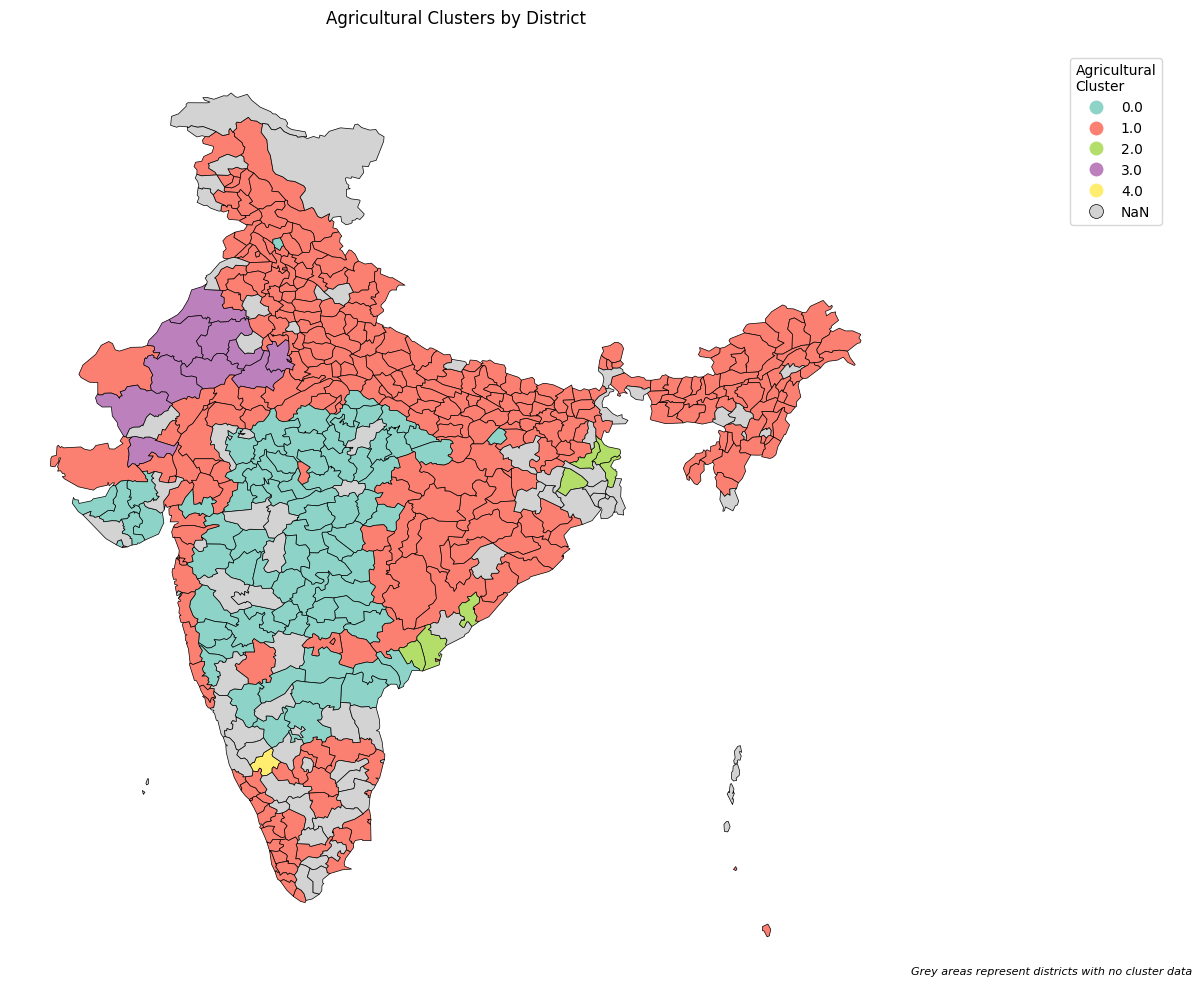

In [13]:
def clean_and_prepare_geo_data(india_dt, cluster_APY):
    """
    Clean and prepare the geographical data with proper column handling
    """
    # Create a copy of the dataframes
    geo_data = india_dt.copy()
    cluster_data = cluster_APY.copy()
    
    # First, let's see what columns we actually have
    print("\nOriginal columns in geo_data:")
    print(geo_data.columns.tolist())
    print("\nOriginal columns in cluster_data:")
    print(cluster_data.columns.tolist())
    
    # Clean district names
    geo_data['DISTRICT_CLEAN'] = geo_data['DISTRICT'].str.strip().str.upper()
    cluster_data['District'] = cluster_data['District'].str.strip().str.upper()
    
    # Perform the merge
    geo_data_merged = geo_data.merge(
        cluster_data,
        left_on='DISTRICT_CLEAN',
        right_on='District',
        how='left'
    )
    
    # Keep it as a GeoDataFrame
    geo_data_new = gpd.GeoDataFrame(geo_data_merged, geometry='geometry')
    
    print("\nColumns after merge:")
    print(geo_data_new.columns.tolist())
    
    # Calculate centroids if not already present
    if 'longitude' not in geo_data_new.columns:
        geo_data_new['longitude'] = geo_data_new.geometry.centroid.x
        geo_data_new['latitude'] = geo_data_new.geometry.centroid.y
    
    # Keep only the columns we need with their original names
    columns_to_keep = [
        'DST_ID', 
        'DISTRICT', 
        'STATE', 
        'geometry',
        'Cluster',  # Use original column name
        'Dominant_Crop',
        'longitude',
        'latitude'
    ]
    
    # Filter columns that actually exist
    existing_columns = [col for col in columns_to_keep if col in geo_data_new.columns]
    
    geo_data_clean = geo_data_new[existing_columns]
    
    print("\nData Summary:")
    print(f"Total districts: {len(geo_data_clean)}")
    print(f"Districts with cluster assignments: {geo_data_clean['Cluster'].notna().sum()}")
    print("\nCluster distribution:")
    print(geo_data_clean['Cluster'].value_counts(dropna=False))
    
    return geo_data_clean

def plot_agricultural_clusters(geo_data):
    """
    Plot agricultural clusters with proper handling of missing values
    """
    fig, ax = plt.subplots(figsize=(15, 10))
    
    # Create the plot
    geo_data.plot(
        ax=ax,
        column='Cluster',
        categorical=True,
        legend=True,
        cmap='Set3',
        missing_kwds={'color': 'lightgrey'},
        edgecolor='black',
        linewidth=0.5,
        legend_kwds={
            'title': 'Agricultural\nCluster',
            'bbox_to_anchor': (1.3, 1)
        }
    )
    
    # Customize the plot
    ax.set_title('Agricultural Clusters by District', pad=20)
    ax.axis('off')
    
    # Add text explaining missing data
    plt.figtext(
        0.99, 0.02,
        'Grey areas represent districts with no cluster data',
        ha='right', fontsize=8, style='italic'
    )
    
    plt.tight_layout()
    plt.show()

# Try the complete analysis with debugging information
try:
    # Clean and prepare the data
    geo_data_clean = clean_and_prepare_geo_data(india_dt, cluster_APY)
    
    # Create the visualization
    plot_agricultural_clusters(geo_data_clean)
    
except Exception as e:
    print(f"\nError in execution: {str(e)}")
    import traceback
    traceback.print_exc()

#### create a detailed_district_report function that can retrive a lot of information about a district's production 

In [14]:
def create_detailed_district_report(district_name, df):
    """Create a detailed report for a specific district"""
    district_data = df[df['District'] == district_name]
    yearly_production = district_data.groupby(['Crop', 'Crop_Year'])['Production'].sum().reset_index()
    
    average_yearly_production = yearly_production.groupby('Crop')['Production'].mean()\
        .sort_values(ascending=False)\
        .head()
    
    print(f"\n=== Detailed Report for {district_name} ===")
    print("\nTop 5 crops by production:")
    print(average_yearly_production)
    
    print("\nSeasonal distribution:")
    print(district_data['Season'].value_counts())
    
    top_crop = district_data.groupby('Crop')['Production'].sum().idxmax()
    yearly_trend = district_data[district_data['Crop'] == top_crop].groupby('Crop_Year')['Production'].sum()
    
    plt.figure(figsize=(10, 6))
    yearly_trend.plot(kind='line')
    plt.title(f'Production Trend of {top_crop} in {district_name}')
    plt.xlabel('Year')
    plt.ylabel('Production')
    plt.show()


#### Using the **create_detailed_district_report** function can retrive a lot of information about a district's production of the crops since 1961 on average. 


=== Detailed Report for GUNTUR ===

Top 5 crops by production:
Crop
Coconut         2.413576e+06
Rice            9.199871e+05
Cotton(lint)    5.179713e+05
Maize           3.774262e+05
Dry chillies    2.739435e+05
Name: Production, dtype: float64

Seasonal distribution:
Rabi           350
Kharif         348
Whole Year     121
Name: Season, dtype: int64


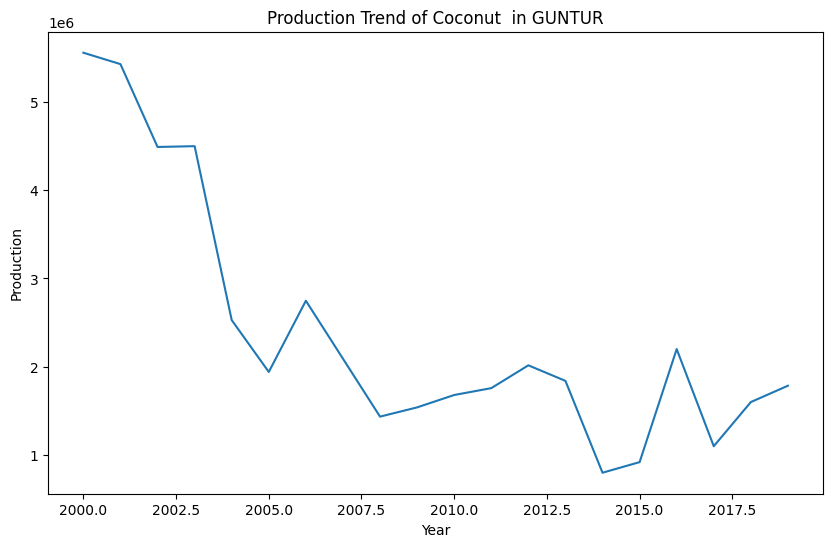

In [15]:
#only enter the district's name in capital letters
create_detailed_district_report('GUNTUR', APY)

### Implementing Time Analysis and forecasting now:

* First create time window, prepare climate features and the build the ltsm model

In [16]:
def prepare_climate_features(rainfall_df, temp_df):
    """
    Create relevant climate features from rainfall and temperature data
    """
    try:
        # Create copies to avoid modifying originals
        rainfall_features = rainfall_df.copy()
        temp_features = temp_df.copy()
        
        # Create a feature DataFrame with YEAR as index
        features = pd.DataFrame()
        features['YEAR'] = rainfall_features['YEAR']
        
        # Add existing seasonal rainfall if available
        if 'Jun-Sep' in rainfall_features.columns:
            features['monsoon_rainfall'] = rainfall_features['Jun-Sep']
            features['pre_monsoon'] = rainfall_features['Mar-May']
            features['post_monsoon'] = rainfall_features['Oct-Dec']
        else:
            # Calculate seasonal rainfall from monthly data
            features['monsoon_rainfall'] = rainfall_features[['JUN', 'JUL', 'AUG', 'SEP']].sum(axis=1)
            features['pre_monsoon'] = rainfall_features[['MAR', 'APR', 'MAY']].sum(axis=1)
            features['post_monsoon'] = rainfall_features[['OCT', 'NOV', 'DEC']].sum(axis=1)
        
        # Add temperature features
        features['annual_temp'] = temp_features['ANNUAL']
        features['temp_variation'] = temp_features['JUN-SEP'] - temp_features['JAN-FEB']
        
        print("\nFeatures created successfully:")
        print(features.columns.tolist())
        print("\nSample of features:")
        print(features.head())
        
        return features
        
    except Exception as e:
        print(f"Error in prepare_climate_features: {str(e)}")
        print("\nAvailable columns in rainfall_df:", rainfall_df.columns.tolist())
        print("\nAvailable columns in temp_df:", temp_df.columns.tolist())
        raise

def create_climate_production_dataset(APY_df, rainfall_df, temp_df, crop_name, district=None):
    """
    Create combined dataset of production and climate data with better error handling
    """
    try:
        # Filter for specific crop and district
        if district:
            crop_data = APY_df[(APY_df['Crop'] == crop_name) & 
                              (APY_df['District'] == district)].copy()
        else:
            crop_data = APY_df[APY_df['Crop'] == crop_name].copy()
        
        print(f"\nFound {len(crop_data)} records for {crop_name} in {district if district else 'all districts'}")
        
        # Group by year
        yearly_production = crop_data.groupby('Crop_Year')['Production'].sum().reset_index()
        yearly_production.columns = ['YEAR', 'Production']
        
        # Prepare climate features
        climate_features = prepare_climate_features(rainfall_df, temp_df)
        
        # Merge production and climate data
        combined_data = pd.merge(yearly_production, climate_features, on='YEAR', how='inner')
        combined_data = combined_data.sort_values('YEAR')
        
        print("\nCombined dataset shape:", combined_data.shape)
        print("\nColumns in combined dataset:", combined_data.columns.tolist())
        print("\nFirst few rows of combined dataset:")
        print(combined_data.head())
        
        return combined_data
        
    except Exception as e:
        print(f"\nError in create_climate_production_dataset: {str(e)}")
        print("\nDebug information:")
        print("APY_df columns:", APY_df.columns.tolist())
        print("Rainfall columns:", rainfall_df.columns.tolist())
        print("Temperature columns:", temp_df.columns.tolist())
        raise

def create_time_windows(data, window_size):
    """
    Create time windows for sequence prediction
    """
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size)])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

def build_lstm_model(input_shape, dropout_rate=0.2):
    """
    Build LSTM model for time series forecasting
    """
    model = Sequential([
    LSTM(64, activation='relu', input_shape=input_shape,
    return_sequences=True),
    Dropout(dropout_rate),
    LSTM(32, activation='relu'),
    Dropout(dropout_rate),
    Dense(16, activation='relu'),
    Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

Now Analyze seasonality and create climate production dataset by:
1. Filtering production data for specific crop/district
2. Then aggregating production by year
3. After which we merge with climate features and return time-ordered dataset with production and climate variables

In [17]:
def analyze_seasonality(data, period=12):
    """
    Analyze seasonal patterns in time series data with error handling
    """
    # Check if we have enough data
    if len(data) < period * 2:
        print(f"Warning: Not enough data for seasonality analysis. Need at least {period * 2} points, but got {len(data)}")
        return None, None
    
    try:
        # Calculate lag correlation
        result = stats.pearsonr(data[:-period], data[period:])
        lag_correlation = result[0]
        
        # Calculate seasonal indices
        seasonal_means = []
        for i in range(period):
            values = data[i::period]
            if len(values) > 0:  # Check if we have values for this season
                seasonal_means.append(np.mean(values))
            else:
                seasonal_means.append(np.nan)
        
        if any(not np.isnan(x) for x in seasonal_means):  # If we have any valid means
            seasonal_index = np.array(seasonal_means) / np.nanmean(seasonal_means)
        else:
            seasonal_index = np.array([np.nan] * period)
        
        return lag_correlation, seasonal_index
    
    except Exception as e:
        print(f"Error in seasonality analysis: {str(e)}")
        return None, None

#Now we create a sequence data using time windows, obviosuly splitting the data into a 80-20 split and training the ltsm model 
def train_production_forecast_model(combined_data, feature_columns, target_column='Production', 
                                  window_size=5, train_split=0.8):
    """
    Train LSTM model for production forecasting
    """
    # Scale data
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(combined_data[feature_columns + [target_column]])
    
    # Create sequences
    X, y = create_time_windows(scaled_data, window_size)
    
    # Split into train and test
    train_size = int(len(X) * train_split)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    
    # Build and train model
    model = build_lstm_model((window_size, len(feature_columns) + 1))
    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        verbose=1
    )
    
    return model, scaler, history

1. Calculate correlations between each climate variable and production
2. Create scatter plots showing relationships
3. Return correlation coefficients

In [18]:
def forecast_future_production(model, scaler, last_sequence, n_steps=10):
    """
    Generate future production forecasts
    """
    current_sequence = last_sequence.copy()
    forecasts = []
    
    for _ in range(n_steps):
        prediction = model.predict(current_sequence.reshape(1, *current_sequence.shape), verbose=0)
        forecasts.append(prediction[0, 0])
        
        # Update sequence
        current_sequence = np.roll(current_sequence, -1, axis=0)
        current_sequence[-1] = prediction
    
    # Inverse transform predictions
    forecast_values = scaler.inverse_transform(
        np.column_stack([np.zeros((len(forecasts), scaler.scale_.shape[0]-1)), forecasts])
    )[:, -1]
    
    return forecast_values

def plot_forecast_results(combined_data, forecast, crop_name, district=None):
    """
    Plot historical data and forecasts
    """
    plt.figure(figsize=(15, 7))
    
    # Plot historical data
    plt.plot(combined_data['YEAR'], combined_data['Production'], 
             label='Historical', linewidth=2)
    
    # Generate future years matching forecast length
    future_years = np.arange(
        combined_data['YEAR'].max() + 1,
        combined_data['YEAR'].max() + len(forecast) + 1
    )
    
    # Plot forecast
    plt.plot(future_years, forecast, '--', label='Forecast', linewidth=2)
    
    # Add confidence intervals (using historical standard deviation)
    std_dev = combined_data['Production'].std()
    plt.fill_between(future_years,
                    forecast - std_dev,
                    forecast + std_dev,
                    alpha=0.2,
                    label='Confidence Interval')
    
    title = f'{crop_name} Production Forecast'
    if district:
        title += f' for {district}'
    plt.title(title)
    plt.xlabel('Year')
    plt.ylabel('Production')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print forecast values
    print("\nForecast Values:")
    print("Year\t\tPredicted Production")
    print("-" * 35)
    for year, value in zip(future_years, forecast):
        print(f"{year}\t\t{value:,.2f}")

### As we can see in the previous few code blocks, the code format allows for data integration of climate dataset with the crop production and figure out their correlation, make an 

In [19]:
def analyze_climate_impact(combined_data):
    """
    Analyze relationship between climate variables and production with improved error handling
    """
    try:
        # Define climate columns that should exist in the data
        climate_cols = ['monsoon_rainfall', 'pre_monsoon', 'post_monsoon', 
                       'annual_temp', 'temp_variation']
        
        # Verify which columns actually exist
        available_cols = [col for col in climate_cols if col in combined_data.columns]
        
        print("\nAnalyzing climate impact for columns:", available_cols)
        
        correlations = {}
        
        # Calculate correlations for available columns
        for col in available_cols:
            # Check for NaN values
            if combined_data[col].isnull().any() or combined_data['Production'].isnull().any():
                print(f"Warning: NaN values found in {col} or Production")
                continue
                
            correlation = stats.pearsonr(combined_data[col], combined_data['Production'])
            correlations[col] = correlation[0]
            print(f"Correlation for {col}: {correlation[0]:.3f}")
        
        # Plot relationships
        if correlations:
            n_cols = len(available_cols)
            fig_width = min(15, 5 * n_cols)
            fig = plt.figure(figsize=(fig_width, 5))
            
            for i, col in enumerate(available_cols, 1):
                plt.subplot(1, n_cols, i)
                plt.scatter(combined_data[col], combined_data['Production'])
                plt.xlabel(col)
                plt.ylabel('Production')
                plt.title(f'Correlation: {correlations[col]:.2f}')
            
            plt.tight_layout()
            plt.show()
        
        return correlations
        
    except Exception as e:
        print(f"\nError in analyze_climate_impact: {str(e)}")
        print("\nDebug information:")
        print("Available columns:", combined_data.columns.tolist())
        print("\nSample of data:")
        print(combined_data.head())
        raise

### As we can see above, the code format allows for data integration of climate dataset with the crop production and figure out their correlation

In [20]:
def plot_forecast_results(historical_data, forecast, crop_name, district):
    """
    Create a comprehensive visualization of the forecast results
    """
    plt.figure(figsize=(15, 10))
    
    # Plot historical data
    plt.subplot(2, 1, 1)
    plt.plot(historical_data.index, historical_data['Production'], 
             label='Historical Production', marker='o')
    plt.title(f'Historical {crop_name} Production in {district}')
    plt.xlabel('Year')
    plt.ylabel('Production')
    plt.grid(True)
    plt.legend()
    
    # Plot forecast with confidence intervals
    plt.subplot(2, 1, 2)
    last_year = historical_data.index[-1]
    forecast_years = range(last_year + 1, last_year + len(forecast) + 1)
    
    plt.plot(historical_data.index[-5:], historical_data['Production'].iloc[-5:], 
             label='Recent Production', marker='o')
    plt.plot(forecast_years, forecast, label='Forecast', marker='s', color='red')
    plt.title(f'{crop_name} Production Forecast for {district}')
    plt.xlabel('Year')
    plt.ylabel('Production')
    plt.grid(True)
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print forecast values
    print("\nProduction Forecast:")
    for year, value in zip(forecast_years, forecast):
        print(f"Year {year}: {value:,.0f}")
    
    # Print correlation analysis
    print("\nClimate Correlation Analysis:")
    for col in historical_data.columns:
        if col != 'Production':
            corr = historical_data[col].corr(historical_data['Production'])
            print(f"{col}: {corr:.3f}")

In [21]:
def main_analysis2(APY_df, rainfall_df, temp_df, crop_name, district=None, n_years=10):
    try:
        print(f"\nAnalyzing {crop_name} production in {district}")
        print("=" * 50)
        
        # Create dataset
        combined_data = create_climate_production_dataset(
            APY_df, rainfall_df, temp_df, crop_name, district
        )
        
        # Analyze climate impact
        climate_correlations = analyze_climate_impact(combined_data)
        
        # Train model and generate forecast
        feature_columns = ['monsoon_rainfall', 'pre_monsoon', 'post_monsoon', 
                         'annual_temp', 'temp_variation']
        model, scaler, history = train_production_forecast_model(
            combined_data, feature_columns
        )
        
        # Generate forecast
        last_sequence = combined_data[feature_columns + ['Production']].iloc[-5:]
        last_sequence_scaled = scaler.transform(last_sequence)
        forecast = forecast_future_production(model, scaler, last_sequence_scaled, n_steps=n_years)
        
        # Plot results
        plot_forecast_results(combined_data, forecast, crop_name, district)
        
        print("\nModel Training Performance:")
        print(f"Final loss: {history.history['loss'][-1]:.4f}")
        print(f"Final MAE: {history.history['mae'][-1]:.4f}")
        
        return {
            'model': model,
            'forecast': forecast,
            'climate_impact': climate_correlations,
            'data': combined_data
        }
        
    except Exception as e:
        print(f"\nError in analysis: {str(e)}")
        raise


Analyzing Rapeseed &Mustard production in AMRITSAR

Found 22 records for Rapeseed &Mustard in AMRITSAR

Features created successfully:
['YEAR', 'monsoon_rainfall', 'pre_monsoon', 'post_monsoon', 'annual_temp', 'temp_variation']

Sample of features:
   YEAR  monsoon_rainfall  pre_monsoon  post_monsoon  annual_temp  \
0  1961            1052.0        132.1         154.2        24.00   
1  1962             906.6        130.4         126.7        24.04   
2  1963             908.2        153.1         142.9        24.15   
3  1964             997.0        111.1         103.5        24.10   
4  1965             708.5        124.6          74.4        24.07   

   temp_variation  
0            8.08  
1            8.23  
2            8.14  
3            8.07  
4            7.86  

Combined dataset shape: (21, 7)

Columns in combined dataset: ['YEAR', 'Production', 'monsoon_rainfall', 'pre_monsoon', 'post_monsoon', 'annual_temp', 'temp_variation']

First few rows of combined dataset:
   YEAR 

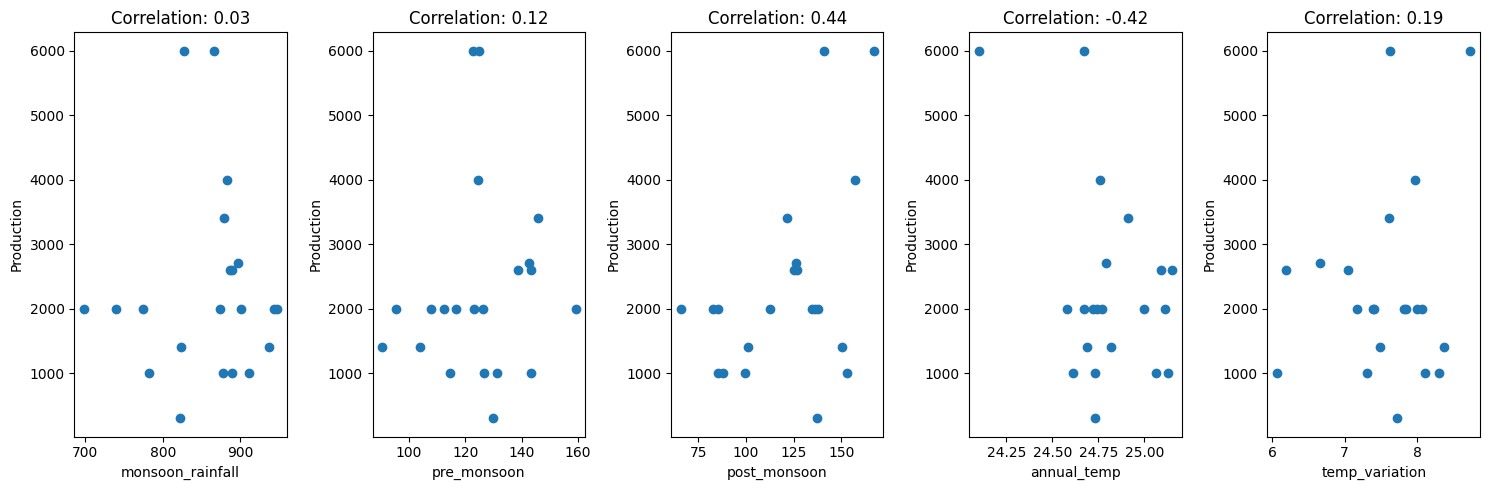

Epoch 1/100


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.3079 - mae: 0.4815 - val_loss: 0.2790 - val_mae: 0.4496
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.2991 - mae: 0.4747 - val_loss: 0.2671 - val_mae: 0.4378
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.2838 - mae: 0.4586 - val_loss: 0.2543 - val_mae: 0.4243
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.2659 - mae: 0.4416 - val_loss: 0.2406 - val_mae: 0.4095
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.2544 - mae: 0.4297 - val_loss: 0.2262 - val_mae: 0.3932
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.2379 - mae: 0.4132 - val_loss: 0.2113 - val_mae: 0.3753
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.2262 - mae: 0.3999 - val_loss: 0.1959 - val_mae: 0.3571
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.2053 - mae: 0.3781 - val_loss: 0.1805 - val_mae: 0.3388
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.1902 - mae: 0.3603 - val_l

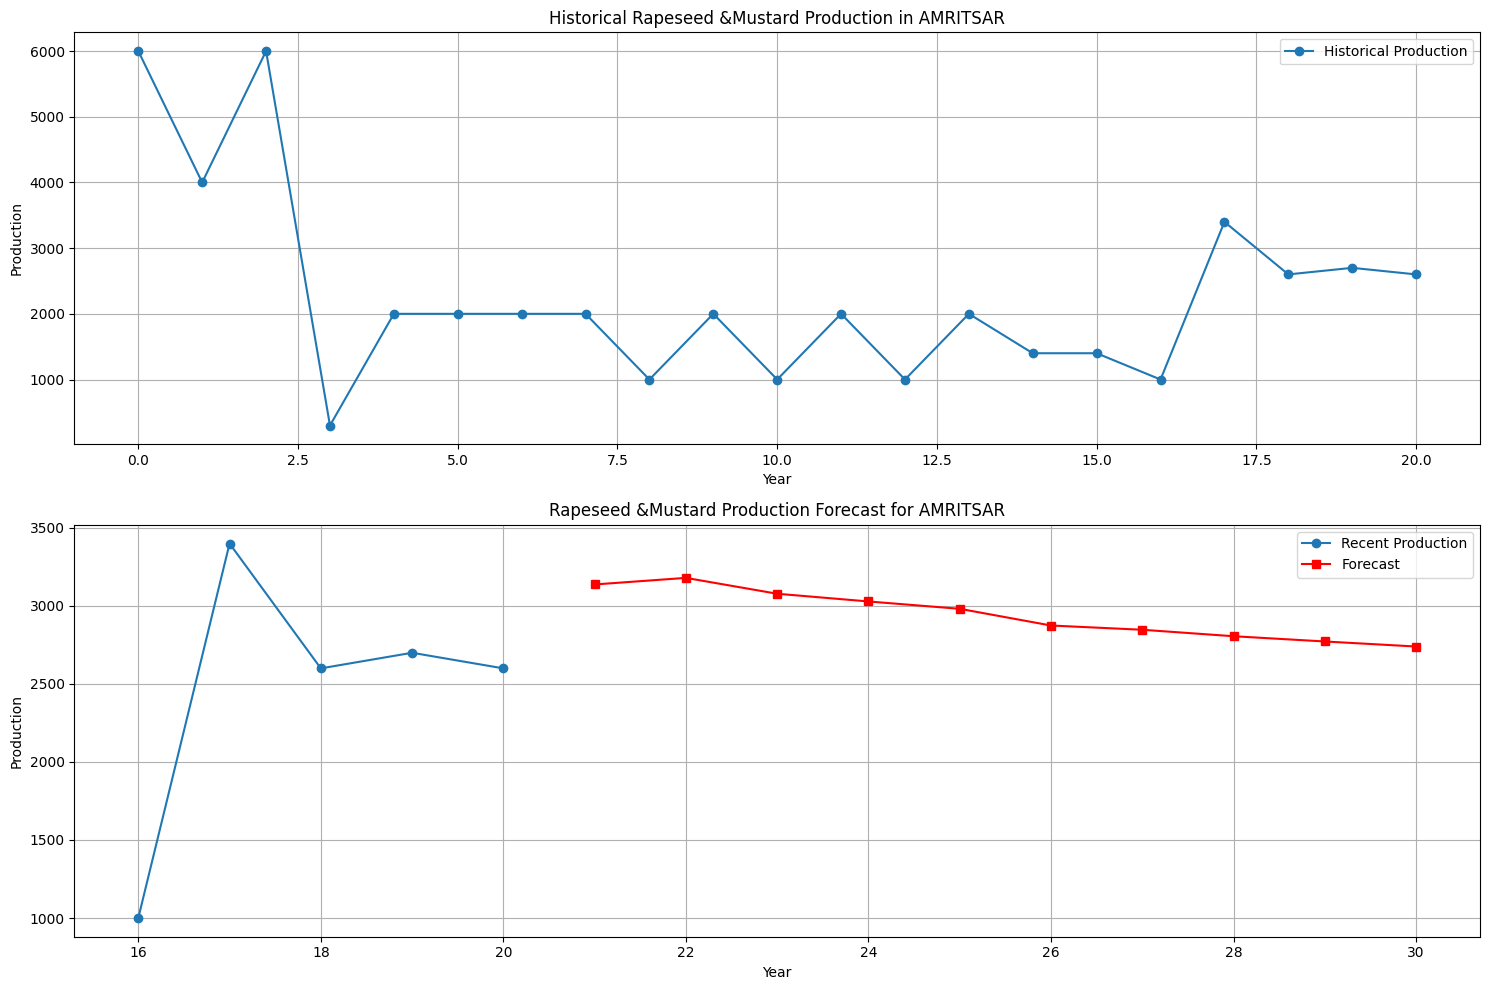


Production Forecast:
Year 21: 3,138
Year 22: 3,180
Year 23: 3,078
Year 24: 3,029
Year 25: 2,982
Year 26: 2,875
Year 27: 2,847
Year 28: 2,806
Year 29: 2,772
Year 30: 2,740

Climate Correlation Analysis:
YEAR: -0.372
monsoon_rainfall: 0.025
pre_monsoon: 0.117
post_monsoon: 0.444
annual_temp: -0.418
temp_variation: 0.188

Model Training Performance:
Final loss: 0.0836
Final MAE: 0.2403


In [26]:
# Try running the analysis with the modified code
try:
    results = main_analysis2(APY, rainfall, temp, crop_name='Rapeseed &Mustard', district='AMRITSAR')
except Exception as e:
    print(f"\nAnalysis failed: {str(e)}")
    print("\nTrying to debug the data:")
    print("\nSample of APY data for Rice in WARANGAL:")
    print(APY[(APY['Crop'] == 'Rice') & (APY['District'] == 'WARANGAL')][['Crop_Year', 'Production']].head())
    print("\nSample of rainfall data:")
    print(rainfall.head())
    print("\nSample of temperature data:")
    print(temp.head())